1: Difference between K-Means and Hierarchical Clustering
-> | Aspect             | K-Means Clustering           | Hierarchical Clustering     |
| ------------------ | ---------------------------- | --------------------------- |
| Type               | Partition-based              | Tree-based                  |
| Number of clusters | Must be specified beforehand | Not required initially      |
| Scalability        | Works well on large datasets | Computationally expensive   |
| Output             | Flat clusters                | Dendrogram (tree structure) |
| Sensitivity        | Sensitive to outliers        | Less sensitive              |

2: Purpose of Silhouette Score
-> The Silhouette Score measures how well data points are clustered by comparing:

Intra-cluster distance (cohesion)
Inter-cluster distance (separation)

Range: -1 to +1

Close to +1 → well-clustered
Around 0 → overlapping clusters
Negative → incorrect clustering

It helps compare clustering quality and choose the best algorithm or parameters.

3: Core Parameters of DBSCAN
-> eps (epsilon):

Maximum distance between two points to be neighbors.
Larger eps → fewer, bigger clusters.

min_samples:

Minimum points required to form a dense region.
Higher value → stricter clustering.

Effect:
These parameters determine density sensitivity, cluster shape, and noise detection.

4: Importance of Feature Scaling
-> Clustering algorithms use distance metrics (Euclidean distance).

Without scaling:

Features with larger ranges dominate.
Clusters become biased.

With scaling:

All features contribute equally.
Better and meaningful clusters.

Common methods: StandardScaler, MinMaxScaler.

5: Elbow Method
-> The Elbow Method plots:

Number of clusters (K) vs Within-Cluster Sum of Squares (WCSS)

The point where WCSS reduction slows down (elbow shape) indicates the optimal K.

This avoids over-clustering and under-clustering.

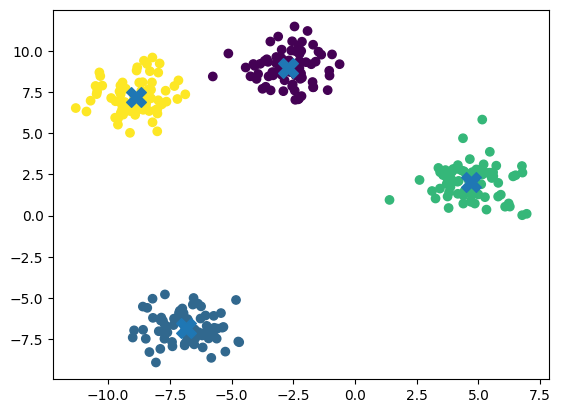

In [1]:
#6: K-Means with make_blobs
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.show()


In [2]:
#7: DBSCAN on Wine Dataset
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

data = load_wine()
X = StandardScaler().fit_transform(data.data)

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters)


Number of clusters: 0


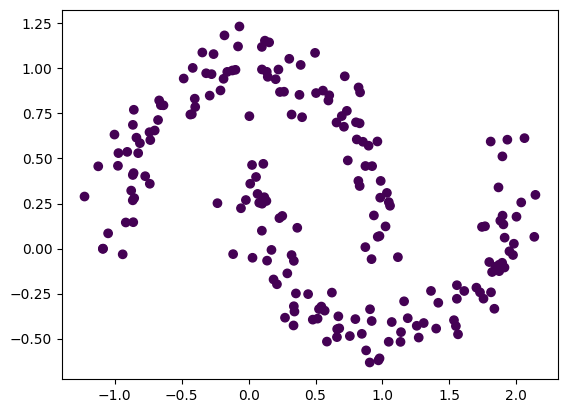

In [3]:
#8: DBSCAN with make_moons
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.show()


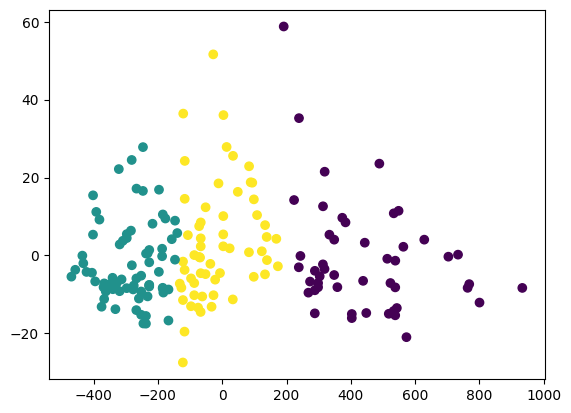

In [4]:
#9: PCA + Agglomerative Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt

data = load_wine()
X = data.data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.show()


10: Real-World Clustering Workflow (E-Commerce)
-> Algorithm Choice

K-Means: Large datasets, fast segmentation.
Hierarchical: Understanding customer relationships.
DBSCAN: Detect outlier customers.

Preprocessing

Handle missing values (mean/median).
Encode categorical data.
Apply StandardScaler.

Choosing Number of Clusters

Elbow Method
Silhouette Score
Business validation

Marketing Benefits

Personalized promotions
Customer lifetime value targeting
Reduced churn
Higher conversion rates